# Nonlinear MPC in closed loop with `scaly.mpc`: a soft track limit, a mismatched plant, IPOPT and SQP

The cart-pole swing-up of `examples/notebooks/nmpc_cartpole.ipynb`, written with `scaly.mpc`
instead of by hand: an `mpc.OCP`, an `mpc.MPC` controller around IPOPT, and `mpc.simulate` running
it in closed loop against a plant that is not the controller's model, an adaptive integration of a
cart-pole whose pole is 20% heavier. The track limit is soft. The notebook shows where it gives way
and why it must, reads whole plans from `ctrl.solve`, runs the control law as one Function the way
a C caller would, and runs the same closed loop with scaly's own SQP.

| Scaly feature | Where |
| --- | --- |
| `mpc.OCP(ode=..., transcription=si.MultipleShooting(si.rk4, steps=2), ...)` | the controller |
| `mpc.Path(position, lo, hi, soft=...)` | the controller; where the soft limit gives way |
| `si.adaptive(model, "dopri5", dt=..., rtol=..., atol=...)` | the plant |
| `ctrl.initial_guess`, `ctrl.reset(guess)`, `ctrl.reset()` | the first solve |
| `mpc.MPC(ocp, "ipopt")`, `mpc.simulate`, `mpc.ClosedLoop` | the closed loop |
| `ctrl.law`, `ctrl.guess_size` | the control law by hand; the generated C |
| `ctrl.solve` and `mpc.Solution` (`xs`, `us`, `slack`, `cost`, `status`, `guess`) | where the soft limit gives way; scaly's SQP |
| `mpc.MPC(ocp, "sqp")` | scaly's SQP |

This notebook needs the vendored IPOPT and the scaly SQP plugin.

In [1]:
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent / "notebooks"))  # the shared plot style
import plotstyle
import scaly as sc
from scaly import integrators as si
from scaly import mpc
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "mpc" / "nmpc_closed_loop"

## The controller

The model, weights and limits are those of `nmpc_cartpole`: cart position $p$, pole angle $\theta$
from upright, their rates, a force $|u| \le 15$ N and a track $|p| \le 1$ m. Every 50 ms the
controller solves

$$
\begin{aligned}
\min_{x, u, s}\ & \Delta t \sum_{k=0}^{N-1} l(x_k, u_k) + l_N(x_N) + \rho \sum_{k=0}^{N-1} s_k \\
\text{s.t.}\ & x_0 = \hat x, \quad x_{k+1} = F(x_k, u_k), \quad |u_k| \le 15, \quad -1 - s_k \le p_k \le 1 + s_k, \quad s_k \ge 0 \quad (k < N),
\end{aligned}
$$

with $F$ two RK4 substeps of $\Delta t = 50$ ms, $N = 40$, $l = 2p^2 + 20\,(1 - \cos\theta)^2 + 0.1\,(\dot p^2 + \dot\theta^2) + 0.02\,u^2$,
$l_N$ ten times its state part, and $\hat x$ the measured state. `mpc.Path(position, lo=-1, hi=1, soft=1e3)`
adds the slacks $s_k$ and their penalty $\rho = 10^3$. The penalty is exact: when the hard limit
can be met, with multipliers below $\rho$, the soft problem has the same solution, and when it
cannot, the soft problem still has one, violating the limit by as little as it can.

In [2]:
NX, NU, N, DT = 4, 1, 40, 0.05
M_CART, M_POLE, LENGTH, G = 1.0, 0.3, 0.5, 9.81
U_MAX, P_MAX, SOFT = 15.0, 1.0, 1e3
Q = np.array([2.0, 20.0, 0.1, 0.1])  # p, 1 - cos(theta), rates
R, QN = 0.02, 10.0
X0 = np.array([0.0, np.pi, 0.0, 0.0])


def dynamics(x, u, m_pole):
  theta, pd, td = x[1], x[2], x[3]
  s, c = theta.sin(), theta.cos()
  den = M_CART + m_pole * s * s
  pdd = (u[0] + m_pole * LENGTH * td * td * s - m_pole * G * s * c) / den
  tdd = (G * s * (M_CART + m_pole) - c * (u[0] + m_pole * LENGTH * td * td * s)) / (LENGTH * den)
  return sc.stack([pd, td, pdd, tdd])


@sc.function(NX, NU, output="xdot", name="closed_loop_cartpole")
def cartpole(x, u):
  return dynamics(x, u, M_POLE)


def error(x):
  return sc.stack([x[0], 1.0 - x[1].cos(), x[2], x[3]])


@sc.function(NX, NU, output="l", name="closed_loop_stage")
def stage(x, u):
  e = error(x)
  return (sc.const(Q) * e * e).sum() + R * u[0] * u[0]


@sc.function(NX, output="vf", name="closed_loop_terminal")
def terminal(x):
  e = error(x)
  return QN * (sc.const(Q) * e * e).sum()


@sc.function(NX, NU, output="p", name="closed_loop_position")
def position(x, u):
  return x[:1]


def ocp(name, soft=SOFT):
  return mpc.OCP(
    ode=cartpole,
    dt=DT,
    horizon=N,
    transcription=si.MultipleShooting(si.rk4, steps=2),
    stage_cost=stage,
    terminal_cost=terminal,
    u_bounds=(-U_MAX, U_MAX),
    constraints=[mpc.Path(position, lo=-P_MAX, hi=P_MAX, soft=soft)],
    name=name,
  )


ctrl = mpc.MPC(ocp("closed_loop_ipopt_ocp"), "ipopt", options={"tol": 1e-8, "max_iter": 500})
layout = ctrl.ocp.layout
print(f"variables {dict(zip(layout.var_names, layout.var_sizes, strict=True))}, {ctrl.n_eq} equalities, {ctrl.n_ineq} inequalities")

variables {'xs': 164, 'us': 40, 'slack': 40}, 164 equalities, 80 inequalities


The variables are the 41 states, the 40 forces and 40 slacks. The 80 inequality rows are the soft
limit's two sides, $p_k - s_k \le 1$ and $p_k + s_k \ge -1$.

## The plant

The plant integrates a cart-pole whose pole weighs 0.36 kg instead of 0.3 kg with `si.adaptive`:
Dormand-Prince 5(4) with error control in a `while_loop`, tolerances 1e-10 and 1e-12, one call per
sample. A second plant integrates the controller's own model the same way, to separate what the
mismatch does from what the controller does.

In [3]:
M_POLE_PLANT = 1.2 * M_POLE


@sc.function(NX, NU, output="xdot", name="closed_loop_heavier")
def heavier(x, u):
  return dynamics(x, u, M_POLE_PLANT)


plant = si.adaptive(heavier, "dopri5", dt=DT, rtol=1e-10, atol=1e-12, name="closed_loop_plant")
nominal_plant = si.adaptive(cartpole, "dopri5", dt=DT, rtol=1e-10, atol=1e-12, name="closed_loop_nominal_plant")

## The first solve

`ctrl.initial_guess(x0)` puts every state at $x_0$ and every force at 0. Hanging still with no
force is a KKT point of the first problem, by symmetry: the cost's gradient in the angle,
$\sin\theta$, is zero at $\theta = \pi$, and nothing favours swinging one way. IPOPT started there
stays there. A warm start whose forces pump the pole, one period over the horizon, breaks the tie;
`warm` builds it from `initial_guess` by replacing the force block, which `ctrl.ocp.layout` locates.

In [4]:
def warm(controller, x, **blocks):
  """controller.initial_guess(x) with the named variable blocks (xs, us, slack) replaced."""
  guess, layout, start = controller.initial_guess(x), controller.ocp.layout, 0
  for name, size in zip(layout.var_names, layout.var_sizes, strict=True):
    if name in blocks:
      guess[start : start + size] = np.ravel(blocks[name])
    start += size
  return guess


def pumping(controller):
  return warm(controller, X0, us=0.5 * U_MAX * np.sin(2 * np.pi * np.arange(N) / N))


hanging = ctrl.solve(X0, guess=ctrl.initial_guess(X0))
hanging_force = float(np.abs(hanging.us).max())
print(
  f"from initial_guess: {hanging.status.name} after {hanging.status.iter} iterations, cost {hanging.cost:.1f}, largest force {hanging_force:.1e} N"
)

from initial_guess: OK after 7 iterations, cost 960.0, largest force 5.9e-14 N


IPOPT converges, in 7 iterations, to the pole hanging still, with a cost of 960 and no force.

## The closed loop

`ctrl.reset(guess)` sets the next call's warm start. `mpc.simulate(ctrl, plant, x0, steps)` then
calls the controller at each sample, applies the first force for 50 ms, and records the solver's
status, iterations and time. Every call after the first starts from the last solution shifted by
one interval. The same loop against the controller's own model follows.

In [5]:
STEPS = 100
ctrl.reset(pumping(ctrl))
run = mpc.simulate(ctrl, plant, X0, STEPS)
ctrl.reset(pumping(ctrl))
nominal = mpc.simulate(ctrl, nominal_plant, X0, STEPS)

t = DT * np.arange(STEPS + 1)
statuses, nominal_statuses = dict(Counter(run.statuses)), dict(Counter(nominal.statuses))
upright = np.abs(np.cos(run.xs[:, 1]) - 1) < 1e-2
upright_from = float(DT * (len(upright) - np.argmin(upright[::-1]))) if upright.any() else np.inf
u_max, p_max, p_max_nominal = float(np.abs(run.us).max()), float(np.abs(run.xs[:, 0]).max()), float(np.abs(nominal.xs[:, 0]).max())
worst = int(np.argmax(np.abs(run.xs[:STEPS, 0])))
it = run.iterations
print(f"heavier pole: statuses {statuses}; model as plant: {nominal_statuses}")
print(
  f"IPOPT iterations: first {it[0]}, then {it[1:].min()} to {it[1:].max()}, median {np.median(it[1:]):.0f}; median solve {1e3 * np.median(run.solve_times):.2f} ms"
)
print(f"upright within 1e-2 for good from t = {upright_from:.2f} s; final state {np.array2string(run.xs[-1], precision=4)}")
print(f"largest |u| {u_max:.3f} N; largest |p| {p_max:.5f} m at step {worst} (model as plant: {p_max_nominal:.7f} m)")

heavier pole: statuses {'OK': 100}; model as plant: {'OK': 100}
IPOPT iterations: first 43, then 6 to 22, median 6; median solve 1.68 ms
upright within 1e-2 for good from t = 2.05 s; final state [ 0.0004 -0.0005  0.0001  0.0013]
largest |u| 15.000 N; largest |p| 1.01067 m at step 17 (model as plant: 1.0000006 m)


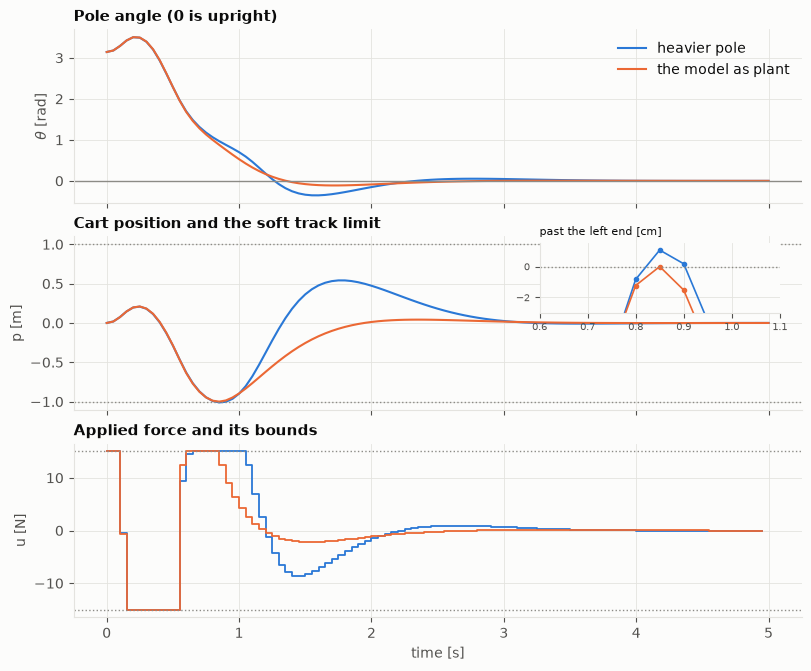

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(8, 6.6), sharex=True)
for series, label, color in ((run, "heavier pole", plotstyle.BLUE), (nominal, "the model as plant", plotstyle.ORANGE)):
  axes[0].plot(t, series.xs[:, 1], color=color, lw=1.5, label=label)
  axes[1].plot(t, series.xs[:, 0], color=color, lw=1.5)
  axes[2].step(t[:-1], series.us[:, 0], where="post", color=color, lw=1.3)
axes[0].axhline(0, color=plotstyle.NEUTRAL, lw=1)
axes[0].set_ylabel(r"$\theta$ [rad]")
axes[0].set_title("Pole angle (0 is upright)")
axes[0].legend(loc="upper right")
for bound in (-P_MAX, P_MAX):
  axes[1].axhline(bound, color=plotstyle.NEUTRAL, lw=1, ls=":")
axes[1].set_ylabel("p [m]")
axes[1].set_title("Cart position and the soft track limit")
zoom = axes[1].inset_axes((0.64, 0.56, 0.33, 0.4))
for series, color in ((run, plotstyle.BLUE), (nominal, plotstyle.ORANGE)):
  zoom.plot(t, 100 * (-series.xs[:, 0] - P_MAX), "o-", ms=3, lw=1.2, color=color)
zoom.axhline(0, color=plotstyle.NEUTRAL, lw=1, ls=":")
zoom.set_xlim(0.6, 1.1)
zoom.set_ylim(-3, 1.5)
zoom.set_title("past the left end [cm]", fontsize=8, fontweight="normal")
zoom.tick_params(labelsize=7)
for bound in (-U_MAX, U_MAX):
  axes[2].axhline(bound, color=plotstyle.NEUTRAL, lw=1, ls=":")
axes[2].set_ylabel("u [N]")
axes[2].set_title("Applied force and its bounds")
axes[2].set_xlabel("time [s]")
plt.show()

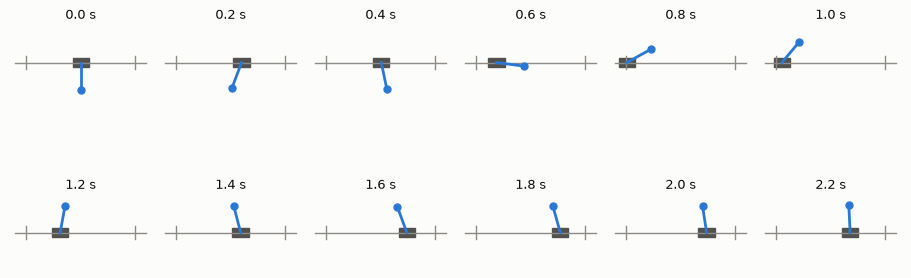

In [7]:
frames = np.arange(0, 48, 4)
fig, axes = plt.subplots(2, 6, figsize=(9, 3.4))
for ax, k in zip(axes.flat, frames, strict=True):
  p, theta = run.xs[k, 0], run.xs[k, 1]
  tip = (p + LENGTH * np.sin(theta), LENGTH * np.cos(theta))
  ax.plot([-P_MAX - 0.2, P_MAX + 0.2], [0, 0], color=plotstyle.NEUTRAL, lw=1)
  for end in (-P_MAX, P_MAX):
    ax.plot([end, end], [-0.12, 0.12], color=plotstyle.NEUTRAL, lw=1)
  ax.add_patch(plt.Rectangle((p - 0.15, -0.08), 0.3, 0.16, color=plotstyle.TEXT_SECONDARY))
  ax.plot([p, tip[0]], [0, tip[1]], color=plotstyle.BLUE, lw=2)
  ax.plot(*tip, "o", color=plotstyle.BLUE, ms=5)
  ax.set_xlim(-1.3, 1.3)
  ax.set_ylim(-0.65, 0.65)
  ax.set_aspect("equal")
  ax.axis("off")
  ax.set_title(f"{t[k]:.1f} s", fontsize=9, fontweight="normal", loc="center")
plt.show()

Against the heavier pole the controller still swings the pole up with one pump. The pole is
upright to within 1e-2 for good from 2.05 s, and after 5 s the state is within 1.3e-3 of the
origin. The heavier pole needs a larger correction after the swing: the force goes down to about
-8.5 N at 1.4 s where the model as plant needs -2 N, and the cart swings out to 0.55 m. Both
loops hold the force at its bounds during the swing. IPOPT takes 43 iterations for the first
solve, 11 to 22 through the swing-up, where the plan changes most between samples, and 6 once the
pole is up, 1.7 ms per solve at the median. The filmstrip shows the heavier-pole run every 0.2 s.

## The control law by hand

`ctrl.law` is the controller as one Function, `law(x0, guess) -> (u, guess_next)`. The solver is
nested in it, and the warm start's shift runs in its own code, so that a caller, in C as in
Python, keeps one buffer of `ctrl.guess_size` doubles and passes it back at every sample.
`ctrl(x)`, and so `mpc.simulate`, calls this same compiled law. Run by hand from the same pumping
start, it must reproduce the closed loop exactly. The loop keeps each sample's warm start for the
next section.

In [8]:
guess, x, xs, guesses = pumping(ctrl), X0, [X0], []
for _ in range(STEPS):
  guesses.append(guess)
  u, guess = ctrl.law(x, guess)
  x = np.asarray(plant(x, u))
  xs.append(x)
law_gap = float(np.abs(np.array(xs) - run.xs).max())
print(f"law{ctrl.law.input_names} -> {ctrl.law.output_names}, guess_size {ctrl.guess_size}")
print(f"by hand, the closed loop to {law_gap:.1e}")

law('x0', 'guess') -> ('u', 'guess_next'), guess_size 732
by hand, the closed loop to 0.0e+00


The guess is the whole primal-dual point: 244 variables, their 244 bound multipliers, 164
equality and 80 inequality multipliers, 732 doubles.

## Where the soft limit gives way

Against the controller's own model the cart stays on the track, to 6e-7, the model's integration
error. Against the heavier pole it runs 1.07 cm past the left end at 0.85 s. `ctrl.solve(x, guess=...)`
returns the whole plan at a state as an `mpc.Solution`, and from the warm start the law had at
that sample it is the plan the closed loop followed. The plans from the start to the worst sample
show from which sample on they need slack. The same OCP with the limit hard (`soft=None`) then
shows whether they had a choice.

In [9]:
hard = mpc.MPC(ocp("closed_loop_hard_ocp", soft=None), "ipopt", options={"tol": 1e-8, "max_iter": 500})
plans = [ctrl.solve(run.xs[k], guess=guesses[k]) for k in range(worst + 1)]
plan_slacks = np.array([float(plan.slack.max()) for plan in plans])
hard_statuses = [hard.solve(run.xs[k], guess=warm(hard, run.xs[k], xs=plans[k].xs, us=plans[k].us)).status.name for k in range(worst + 1)]
needs = int(np.argmax(plan_slacks > 1e-6))  # the first plan that gives way
at = plans[worst]
slack_now, slack_next, slack_rest = float(at.slack[0]), float(at.slack[1]), float(np.abs(at.slack[2:]).max())
worst_u_gap = float(np.abs(at.us[0] - run.us[worst]).max())
ctrl.reset()
print(f"{'step':>4} {'largest planned slack':>22} {'hard limit':>18}")
for k in range(needs - 2, worst + 1):
  print(f"{k:4d} {plan_slacks[k]:22.1e} {hard_statuses[k]:>18}")
print(f"hard limit OK up to step {needs - 1}, {Counter(hard_statuses[needs:])} from step {needs}")
print(f"step {worst}: slack {slack_now:.5f} now, {slack_next:.1e} at the next stage, within {slack_rest:.0e} of zero after")
print(
  f"its first force is the closed loop's to {worst_u_gap:.0e}; Solution { ({k: np.shape(getattr(at, k)) for k in ('xs', 'us', 'slack', 'times', 'guess')}) }, zs {at.zs}"
)

step  largest planned slack         hard limit
  11               -1.0e-08                 OK
  12               -1.0e-08                 OK
  13                1.9e-03  PRIMAL_INFEASIBLE
  14                5.1e-03  PRIMAL_INFEASIBLE
  15                8.1e-03  PRIMAL_INFEASIBLE
  16                1.0e-02  PRIMAL_INFEASIBLE
  17                1.1e-02  PRIMAL_INFEASIBLE
hard limit OK up to step 12, Counter({'PRIMAL_INFEASIBLE': 5}) from step 13
step 17: slack 0.01067 now, 1.1e-03 at the next stage, within 1e-08 of zero after
its first force is the closed loop's to 0e+00; Solution {'xs': (41, 4), 'us': (40, 1), 'slack': (40,), 'times': (41,), 'guess': (732,)}, zs None


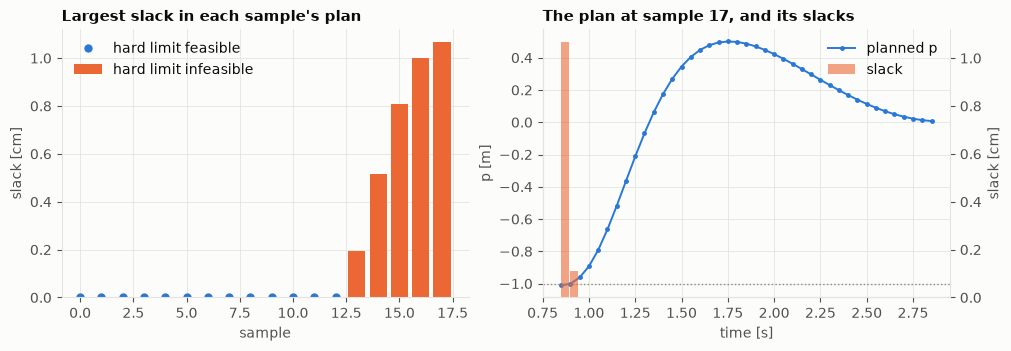

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))
feasible = np.array([s == "OK" for s in hard_statuses])
steps = np.arange(worst + 1)
ax1.plot(steps[feasible], 100 * np.maximum(plan_slacks[feasible], 0), "o", color=plotstyle.BLUE, label="hard limit feasible")
ax1.bar(steps[~feasible], 100 * plan_slacks[~feasible], color=plotstyle.ORANGE, label="hard limit infeasible")
ax1.set_xlabel("sample")
ax1.set_ylabel("slack [cm]")
ax1.set_title("Largest slack in each sample's plan")
ax1.legend(loc="upper left")
horizon = DT * (worst + np.arange(N + 1))
ax2.plot(horizon, at.xs[:, 0], "o-", ms=2.5, color=plotstyle.BLUE, lw=1.4, label="planned p")
ax2.axhline(-P_MAX, color=plotstyle.NEUTRAL, lw=1, ls=":")
ax2.set_ylabel("p [m]")
ax2.set_xlabel("time [s]")
ax2.set_title(f"The plan at sample {worst}, and its slacks")
slack_axis = ax2.twinx()
slack_axis.bar(horizon[:-1], 100 * np.maximum(at.slack, 0), width=0.8 * DT, align="edge", color=plotstyle.ORANGE, alpha=0.6, label="slack")
slack_axis.set_ylabel("slack [cm]")
slack_axis.grid(False)
slack_axis.spines["right"].set_visible(True)
ax2.legend(handles=[*ax2.get_legend_handles_labels()[0], *slack_axis.get_legend_handles_labels()[0]], loc="upper right")
plt.show()

Up to sample 12 every plan keeps the cart on the track, and the hard-limit OCP has a solution at
each of those states. From sample 13 on, the heavier pole has carried the cart where the model can
no longer stop it before the end: every plan needs slack, 0.19 cm at sample 13 growing to 1.07 cm
at sample 17, and at every one of those states the hard-limit OCP has no solution, which IPOPT
reports as `PRIMAL_INFEASIBLE`. The soft limit gives way only where the hard one has no solution.
At sample 17 the cart is 1.067 cm past the end. The plan's first slack is exactly that violation,
the next 0.11 cm, which the cart's momentum makes unavoidable, and every later one zero: the plan
brings the cart back and swings it out to 0.5 m before returning to the origin. `ctrl.solve` from
the law's warm start returns the closed loop's force exactly.

## Scaly's SQP

`mpc.MPC(ocp, "sqp")` puts scaly's own SQP, a filter line search around PIQP generated as C, where
IPOPT was: the same OCP, the same layout of the warm start. The QP subproblems get 200 iterations
and a tolerance of 1e-9; with the plugin's defaults (50 and 1e-6) the first swing-up solve ends at the
iteration limit.

In [11]:
sqp = mpc.MPC(ocp("closed_loop_sqp_ocp"), "sqp", options={"tol": 1e-8, "max_iter": 300, "qp_max_iter": 200, "qp_tol": 1e-9})
sqp_cold = sqp.solve(X0, guess=pumping(sqp))
print(f"SQP from the pumping guess: {sqp_cold.status.name}, cost {sqp_cold.cost:.2f} after {sqp_cold.status.iter} iterations")
print(f"IPOPT from the same guess:  {plans[0].status.name}, cost {plans[0].cost:.2f} after {it[0]} iterations")
sqp.reset(plans[0].guess)  # IPOPT's first solution, primal and dual
sqp_run = mpc.simulate(sqp, plant, X0, STEPS)
sqp_statuses, sqp_iterations = dict(Counter(sqp_run.statuses)), sqp_run.iterations
sqp_state_gap, sqp_force_gap = float(np.abs(sqp_run.xs - run.xs).max()), float(np.abs(sqp_run.us - run.us).max())
print(f"SQP seeded with IPOPT's first solution: statuses {sqp_statuses}")
print(
  f"iterations {sqp_iterations.min()} to {sqp_iterations.max()}, median {np.median(sqp_iterations):.0f}; median solve {1e3 * np.median(sqp_run.solve_times):.2f} ms"
)
print(f"states within {sqp_state_gap:.1e} and forces within {sqp_force_gap:.1e} of IPOPT's closed loop")

SQP from the pumping guess: OK, cost 80.90 after 197 iterations
IPOPT from the same guess:  OK, cost 53.65 after 43 iterations


SQP seeded with IPOPT's first solution: statuses {'OK': 100}
iterations 1 to 7, median 2; median solve 1.04 ms
states within 4.8e-06 and forces within 4.6e-05 of IPOPT's closed loop


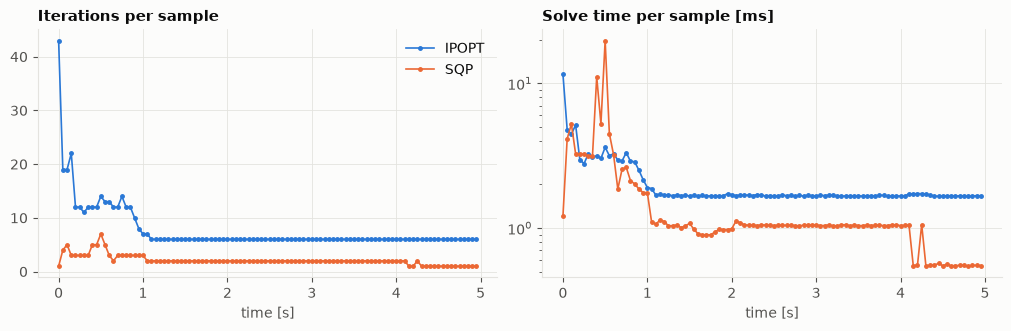

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.2))
ax1.plot(t[:-1], run.iterations, "o-", ms=2.5, lw=1.2, color=plotstyle.BLUE, label="IPOPT")
ax1.plot(t[:-1], sqp_iterations, "o-", ms=2.5, lw=1.2, color=plotstyle.ORANGE, label="SQP")
ax1.set_xlabel("time [s]")
ax1.set_title("Iterations per sample")
ax1.legend(loc="upper right")
ax2.semilogy(t[:-1], 1e3 * run.solve_times, "o-", ms=2.5, lw=1.2, color=plotstyle.BLUE)
ax2.semilogy(t[:-1], 1e3 * sqp_run.solve_times, "o-", ms=2.5, lw=1.2, color=plotstyle.ORANGE)
ax2.set_xlabel("time [s]")
ax2.set_title("Solve time per sample [ms]")
plt.show()

From the pumping guess SQP converges to a worse local minimum, a cost of 80.90 against IPOPT's
53.65, after 197 iterations to IPOPT's 43. Seeded with IPOPT's first solution
(`sqp.reset(plans[0].guess)`) it runs the same closed loop: every solve OK, the states within
4.8e-6 and the forces within 4.6e-5 of IPOPT's, the two solvers' tolerances. From a shifted
solution SQP needs 1 to 7 iterations, 2 at the median and 1 at the end, where IPOPT never needs
fewer than 6: an interior-point method starts every solve from its barrier parameter and follows
it down again. SQP's time follows the QP subproblems inside it: about 1 ms a sample once the pole
is up, and up to 20 ms at the few swing-up samples where PIQP needs hundreds of iterations.

## Checks

In [13]:
iterations = run.iterations
assert statuses == nominal_statuses == sqp_statuses == {"OK": 100}
assert hanging_force < 1e-6
assert iterations[0] > 2 * np.median(iterations[1:])  # the warm start
assert upright_from < 3.0 and np.abs(run.xs[-1]).max() < 1e-2
assert u_max <= 15 + 1e-6
assert p_max_nominal < 1 + 1e-5 and 1.001 < p_max < 1.05  # the soft track limit gives way on the heavier pole
assert hard_statuses[needs - 1 : needs + 1] == ["OK", "PRIMAL_INFEASIBLE"]  # exactly where a hard limit has no solution
assert set(hard_statuses[:needs]) == {"OK"} and set(hard_statuses[needs:]) == {"PRIMAL_INFEASIBLE"}
assert plan_slacks[needs - 1] < 1e-6 and plan_slacks[needs] > 1e-4
assert abs(slack_now - (p_max - 1)) < 1e-6 and slack_rest < 1e-6
assert worst_u_gap < 1e-8 and law_gap < 1e-12
assert ctrl.guess_size == 732 and ctrl.law.input_names == ("x0", "guess") and ctrl.law.output_names == ("u", "guess_next")
assert sqp_state_gap < 5e-5 and sqp_force_gap < 5e-4
assert np.median(sqp_iterations) < np.median(iterations[1:]) and sqp_iterations.max() <= 20
print("14 checks passed")

14 checks passed


## The generated C

`write_module(ctrl.law, ...)` writes the controller as one C module: the law, IPOPT's generated
wrapper and the oracles of the OCP. It links against the vendored IPOPT.

In [14]:
module = write_module(ctrl.law, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.0f} kB; the typed buffers in {module.header_name}:")
print(
  "\n".join(line for line in module.header.splitlines() if line.startswith("typedef struct") and "double data[" in line and "workspace" not in line)
)

closed_loop_ipopt_ocp_law.c: 2581 lines, 203 kB; the typed buffers in closed_loop_ipopt_ocp_law.h:
typedef struct { SCALY_ALIGNAS(16) double data[4]; } closed_loop_ipopt_ocp_law_x0_t;
typedef struct { SCALY_ALIGNAS(16) double data[732]; } closed_loop_ipopt_ocp_law_guess_t;
typedef struct { SCALY_ALIGNAS(16) double data[1]; } closed_loop_ipopt_ocp_law_u_t;
typedef struct { SCALY_ALIGNAS(16) double data[732]; } closed_loop_ipopt_ocp_law_guess_next_t;
